# **EDA Notebook Sales Territory**



---
## 0. Setup Environment

In [1]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT3",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 71.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
Mounted at /content/gdrive

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT3/data


---
## Student Information

In [2]:
group_name = "20"
student_name = "Shanu Sharma"
student_id = "25979360"

In [3]:
# Do not modify this code
print_tile(size="h1", key='group_name', value=group_name)

In [4]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [5]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [6]:
# No additional packages required for this EDA notebook.

### 0.b Import Packages

In [7]:
# Import packages used for data inspection and plotting.
import pandas as pd
from matplotlib import pyplot as plt

---
## B. Data Understanding

In [8]:
# Do not modify this code
try:
  df = pd.read_csv(at.folder_path / "sales_territory.csv")
except Exception as e:
  print(e)

### B.1 Explore Dataset

In [9]:
# Preview the first records to understand the dataset structure.
df.head()


,territory_id,name,CountryRegionCode,group,sales_ytd,sales_last_year,cost_ytd,cost_last_year
0,0ad4c625-bb65-4376-8a41-0a65719b0db8,France,FR,Europe,4.772398e+06,2.396540e+06,0.0,0.0
1,25d73ad2-9e13-410b-8b0d-5f26e2b9e4f2,Germany,DE,Europe,3.805202e+06,1.307950e+06,0.0,0.0
2,2ac923e9-3043-4f5e-bae0-ad28089bf187,Australia,AU,Pacific,5.977815e+06,2.278549e+06,0.0,0.0
3,e0e3bac4-790e-4617-84b3-be0c2bdb7070,United Kingdom,GB,Europe,5.012905e+06,1.635823e+06,0.0,0.0


In [10]:
# Check data types and missing values for each column.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   territory_id       4 non-null      object 
 1   name               4 non-null      object 
 2   CountryRegionCode  4 non-null      object 
 3   group              4 non-null      object 
 4   sales_ytd          4 non-null      float64
 5   sales_last_year    4 non-null      float64
 6   cost_ytd           4 non-null      float64
 7   cost_last_year     4 non-null      float64
dtypes: float64(4), object(4)
memory usage: 388.0+ bytes


In [11]:
# Check the number of rows and columns.
df.shape


(4, 8)

In [12]:
# Summarise the numeric sales and cost columns.
df.describe()

,sales_ytd,sales_last_year,cost_ytd,cost_last_year
count,4.000000e+00,4.000000e+00,4.0,4.0
mean,4.892080e+06,1.904715e+06,0.0,0.0
std,8.923837e+05,5.196392e+05,0.0,0.0
min,3.805202e+06,1.307950e+06,0.0,0.0
25%,4.530599e+06,1.553855e+06,0.0,0.0
50%,4.892652e+06,1.957186e+06,0.0,0.0
75%,5.254133e+06,2.308047e+06,0.0,0.0
max,5.977815e+06,2.396540e+06,0.0,0.0


In [13]:
# Count unique values to identify IDs, categorical fields, and constant columns.
df.nunique()

,0
territory_id,4
name,4
CountryRegionCode,4
group,2
sales_ytd,4
sales_last_year,4
cost_ytd,1
cost_last_year,1


In [14]:
# Check duplicate rows and duplicate business identifiers.
print(f"Duplicates in the dataset: {df.duplicated().sum()}")
print(f"Duplicates in the territory_id: {df['territory_id'].duplicated().sum()}")
print(f"Duplicates in the name: {df['name'].duplicated().sum()}")

Duplicates in the dataset: 0
Duplicates in the territory_id: 0
Duplicates in the name: 0


In [15]:
dataset_insights = """
This EDA is guided by a broad business opportunity: helping the retailer use existing transaction data to understand product, pricing, promotion, and inventory patterns. The working clustering direction is product-level clustering for margin-risk insight. Because clustering is unsupervised, this notebook does not assume the final product groups in advance; it checks whether territory-level information provides useful context or join support for later product profiles.

The sales_territory dataset contains 4 rows and 8 columns. Each row represents one sales territory: France, Germany, Australia, and United Kingdom.

There are no missing values and no duplicate rows. The territory_id and name columns are both unique. territory_id is a valid join key for order, customer, or territory analysis, but it does not directly connect to the product-level datasets needed for the selected clustering use case. The pricing, cost, offer, and sales-detail datasets are linked mainly through product_id and special_offer_id.

The useful business fields are sales_ytd and sales_last_year because they describe territory-level sales performance. However, cost_ytd and cost_last_year contain only zero values, so they do not provide useful information for analysis or modelling.

The business implication is that sales_territory can help interpret regional performance, but it cannot drive the main product clustering solution by itself. For the final clustering use case, the modelling unit should be product, not territory. Territory is not required for the current margin-risk product clustering pipeline because it does not connect directly to product-level price, cost, discount, or promotion features.
"""

In [16]:
# Do not modify this code
print_tile(size="h3", key='dataset_insights', value=dataset_insights)

### B.2 Explore Feature of Interest `name`

In [17]:
# Select territory name for categorical review.
feature = "name"

In [18]:
# Count records by territory name.
df[feature].value_counts()


,count
name,
France,1
Germany,1
Australia,1
United Kingdom,1


In [19]:
# Confirm how many unique territory names exist.
df[feature].nunique()


4

In [20]:
# Check whether territory name has missing values.
df[feature].isnull().sum()


np.int64(0)

<Axes: xlabel='name'>

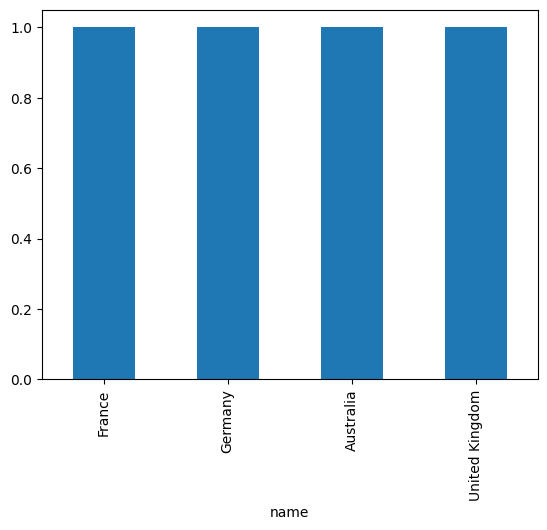

In [21]:
# Plot territory names to confirm each territory appears once.
df[feature].value_counts().plot(kind="bar")


In [22]:
# B.2 insight: territory name.
name_insights = """
The name feature identifies the sales territory. All 4 territory names are unique and there are no missing values.

This column is useful for labelling charts and interpreting business results, but it should not be used directly as a numeric modelling feature. In the final product-level clustering workflow, territory name is not a modelling feature because it labels regions rather than describing product behaviour.
"""

In [23]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=name_insights)

### B.3 Explore Feature of Interest `CountryRegionCode`

In [24]:
# Select country/region code for categorical review.
feature = "CountryRegionCode"


In [25]:
# Count records by country/region code.
df[feature].value_counts()


,count
CountryRegionCode,
FR,1
DE,1
AU,1
GB,1


In [26]:
# Confirm how many unique country/region codes exist.
df[feature].nunique()


4

In [27]:
# Check whether country/region code has missing values.
df[feature].isnull().sum()


np.int64(0)

<Axes: xlabel='CountryRegionCode'>

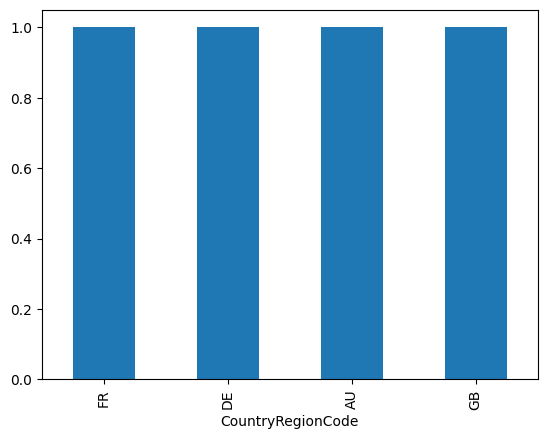

In [28]:
# Plot country/region codes to inspect their distribution.
df[feature].value_counts().plot(kind="bar")


In [29]:
# B.3 insight: country/region code.
country_region_code_insights = """
CountryRegionCode has 4 unique values: FR, DE, AU, and GB. Each code maps directly to one territory name, so it does not add new information beyond the territory identity in this small dataset.

This feature is useful for geographic interpretation, but it is not a strong modelling feature by itself. If territory-level context is used later, the code should be treated as a categorical descriptor rather than a numeric variable.
"""

In [30]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=country_region_code_insights)

### B.4 Explore Feature of Interest `group`

In [31]:
# Select region group for categorical review.
feature = "group"


In [32]:
# Count territories by region group.
df[feature].value_counts()


,count
group,
Europe,3
Pacific,1


In [33]:
# Confirm how many region groups exist.
df[feature].nunique()


2

In [34]:
# Check whether region group has missing values.
df[feature].isnull().sum()


np.int64(0)

<Axes: xlabel='group'>

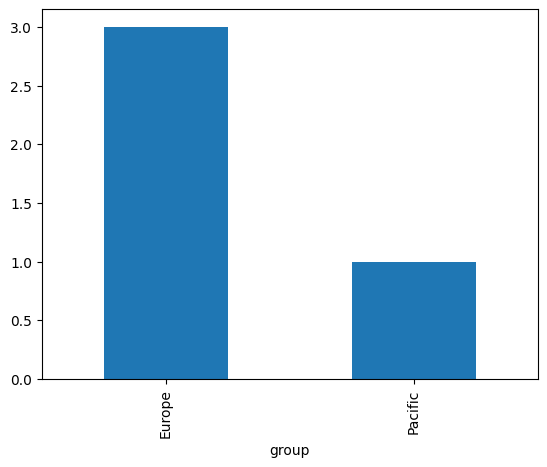

In [35]:
# Plot region group distribution.
df[feature].value_counts().plot(kind="bar")


In [36]:
# B.4 insight: region group.
group_insights = """
The group feature separates territories into Europe and Pacific. Europe contains 3 territories, while Pacific contains only 1 territory.

This feature gives useful regional context, but it is highly imbalanced and the dataset is very small. It can help explain territory-level business differences, but it is not enough to support a reliable clustering model on its own.
"""

In [37]:
# Do not modify this code
print_tile(size="h3", key='feature_3_insights', value=group_insights)

### B.5 Explore Feature of Interest `sales_ytd`

In [38]:
# Select current year-to-date sales for numeric review.
feature = "sales_ytd"


In [39]:
# Summarise current year-to-date sales.
df[feature].describe().round(2)


,sales_ytd
count,4.00
mean,4892080.23
std,892383.66
min,3805202.35
25%,4530599.32
50%,4892651.84
75%,5254132.75
max,5977814.92


In [40]:
# Rank territories by current year-to-date sales.
df[["name", feature]].round(2).sort_values(feature, ascending=False)


,name,sales_ytd
2,Australia,5977814.92
3,United Kingdom,5012905.37
0,France,4772398.31
1,Germany,3805202.35


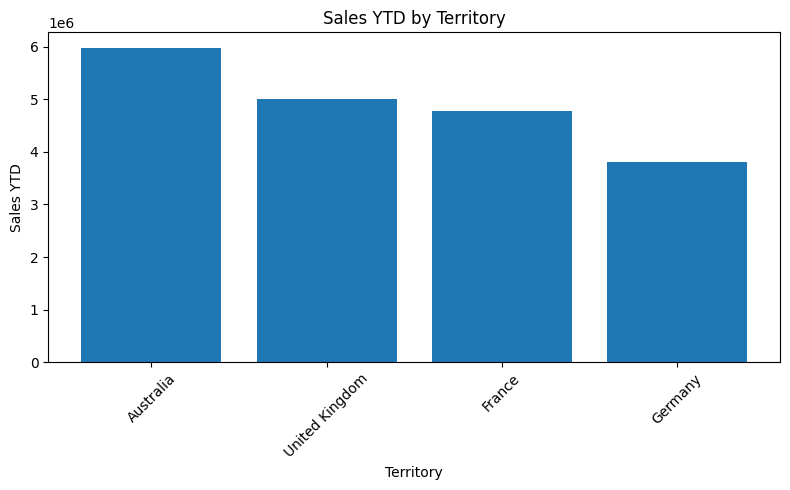

In [41]:
# Plot current year-to-date sales by territory.
df_sorted = df.sort_values("sales_ytd", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(df_sorted["name"], df_sorted[feature])
plt.title("Sales YTD by Territory")
plt.xlabel("Territory")
plt.ylabel("Sales YTD")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [42]:
# B.5 insight: current year-to-date sales.
sales_ytd_insights = """
sales_ytd measures current year-to-date sales by territory. Australia has the highest sales_ytd at approximately 5.98 million, followed by the United Kingdom at approximately 5.01 million, France at approximately 4.77 million, and Germany at approximately 3.81 million.

This feature is useful for understanding territory performance. However, because there are only four territories, sales_ytd alone cannot support a robust clustering model. It is better used as contextual information or as part of a richer aggregated dataset if territory-level analysis is required.
"""

In [43]:
# Do not modify this code
print_tile(size="h3", key='feature_4_insights', value=sales_ytd_insights)

### B.6 Explore Feature of Interest `sales_last_year`

In [44]:
# Select previous-year sales for numeric review.
feature = "sales_last_year"


In [45]:
# Summarise previous-year sales.
df[feature].describe().round(2)


,sales_last_year
count,4.00
mean,1904715.48
std,519639.25
min,1307949.79
25%,1553855.00
50%,1957186.19
75%,2308046.67
max,2396539.76


In [46]:
# Rank territories by previous-year sales.
df[["name", feature]].round(2).sort_values(feature, ascending=False)


,name,sales_last_year
0,France,2396539.76
2,Australia,2278548.98
3,United Kingdom,1635823.40
1,Germany,1307949.79


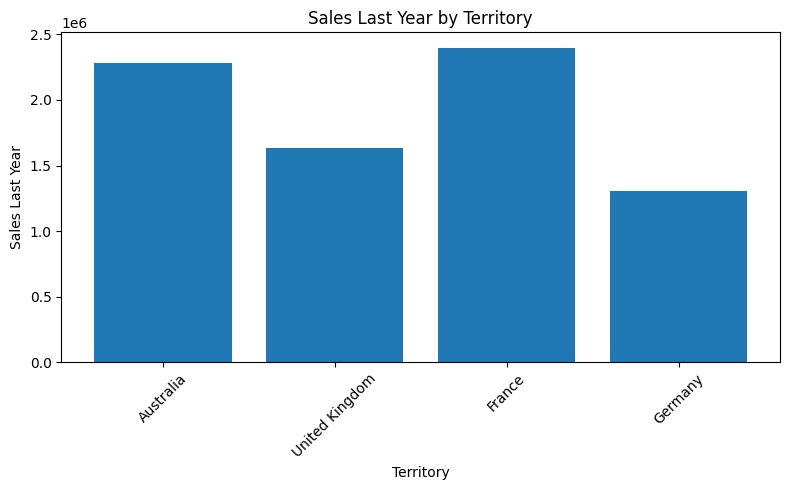

In [47]:
# Plot previous-year sales using the same territory order as current sales.
df_sorted = df.sort_values("sales_ytd", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(df_sorted["name"], df_sorted[feature])
plt.title("Sales Last Year by Territory")
plt.xlabel("Territory")
plt.ylabel("Sales Last Year")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [48]:
# B.6 insight: previous-year sales.
sales_last_year_insights = """
sales_last_year measures each territory's sales in the previous year. France had the highest prior-year sales at approximately 2.40 million, followed by Australia at approximately 2.28 million, the United Kingdom at approximately 1.64 million, and Germany at approximately 1.31 million.

Comparing sales_last_year with sales_ytd shows that every territory increased sales in the current year. This is useful for understanding growth, but the feature is still too high-level to support clustering by itself. It can be used to engineer a growth feature if territory context is later included.
"""


In [49]:
# Do not modify this code
print_tile(size="h3", key='feature_5_insights', value=sales_last_year_insights)

### B.7 Features not included in the Feature of Interest `cost_ytd`, `cost_last_year`, and `territory_id`

In [50]:
# Summarise current year-to-date cost values.
df["cost_ytd"].describe()


,cost_ytd
count,4.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


In [51]:
# Confirm whether current cost has any variation.
print(df["cost_ytd"].unique())
print(df["cost_ytd"].nunique())


[0.]
1


In [52]:
# Summarise previous-year cost values.
df["cost_last_year"].describe()


,cost_last_year
count,4.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


In [53]:
# Confirm whether previous-year cost has any variation.
print(f"Number of unique cost_last_year: {df['cost_last_year'].nunique()}")


Number of unique cost_last_year: 1


In [54]:
# Validate territory_id as a complete and unique join key.
print(f"Number of unique territory_id: {df['territory_id'].nunique()}")
print(f"Null in territory_id: {df['territory_id'].isnull().sum()}")
print(f"Duplicates in territory_id: {df['territory_id'].duplicated().sum()}")


Number of unique territory_id: 4
Null in territory_id: 0
Duplicates in territory_id: 0


In [55]:
# B.7 insight: excluded fields and optional join key.
excluded_feature_insights = """
Excluded fields and join key: from an analysis perspective, only variables that can describe meaningful differences or support later interpretation should be carried forward. cost_ytd and cost_last_year contain only zero values for all territories, so they cannot explain regional differences or support the final clustering solution.

territory_id is complete and unique for all 4 rows, but it is not a core feature for the product-level clustering workflow. The main product-level tables connect through product_id and special_offer_id. Therefore, territory_id should not be used as a clustering feature in the current pipeline.
"""

In [56]:
# Do not modify this code
print_tile(size="h3", key='feature_6_insights', value=excluded_feature_insights)

### B.8 Overall Summary

In [57]:
# Create derived sales metrics for the overall summary.
df_summary = df.copy()
df_summary["sales_growth"] = df_summary["sales_ytd"] - df_summary["sales_last_year"]
df_summary["sales_growth_pct"] = df_summary["sales_growth"] / df_summary["sales_last_year"]
df_summary["sales_ytd_share"] = df_summary["sales_ytd"] / df_summary["sales_ytd"].sum()

df_summary[[
    "name",
    "group",
    "sales_ytd",
    "sales_last_year",
    "sales_growth",
    "sales_growth_pct",
    "sales_ytd_share",
]].round(4).sort_values("sales_ytd", ascending=False)


,name,group,sales_ytd,sales_last_year,sales_growth,sales_growth_pct,sales_ytd_share
2,Australia,Pacific,5.977815e+06,2.278549e+06,3.699266e+06,1.6235,0.3055
3,United Kingdom,Europe,5.012905e+06,1.635823e+06,3.377082e+06,2.0645,0.2562
0,France,Europe,4.772398e+06,2.396540e+06,2.375859e+06,0.9914,0.2439
1,Germany,Europe,3.805202e+06,1.307950e+06,2.497253e+06,1.9093,0.1945


In [58]:
# B.8 insight: overall EDA summary.
overall_summary_insights = """
This notebook shows how sales_territory fits into the broader analysis workflow rather than treating it as an isolated dataset. The retailer's broad problem is to turn transactional data into useful decisions around products, pricing, promotions, and inventory. For the clustering component, the working direction is product-level clustering for margin-risk insight.

sales_territory is clean and useful for regional business context, but it is not central to the product-level clustering dataset. The selected clustering scope is product-level, and the main linked key across the relevant datasets is product_id, supported by special_offer_id for promotion behaviour. sales_territory uses territory_id and has no product_id, so it cannot directly contribute product-level clustering features.

The cost columns should also be excluded because they contain only zero values. For the current workflow, this EDA supports excluding territory from the modelling pipeline. The final model should focus on products because product-level datasets provide richer sales, pricing, cost, discount, promotion, and margin-related signals. sales_territory can still be used by the wider group or in future work if regional product segmentation becomes a separate objective.
"""


In [59]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=overall_summary_insights)